<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>

# Road Hazard Detection by Semantic Segmentation (U-Net)
The goal of this hands-on session is to give you a feel for what semantic segmentation is.


## What Is Semantic Segmentation?


Semantic segmentation (also called region classification or region partitioning) assigns a label to every individual pixel of an image, tagging (classifying) the subject on a pixel-by-pixel basis.

Compared with bounding-box detection, one advantage is that it can also assign labels to irregularly shaped regions (for example, the sky).

It is a technology used in situations where subjects must be identified, such as in self-driving vehicles and in medical images like X-rays.

Example illustration of segmentation:
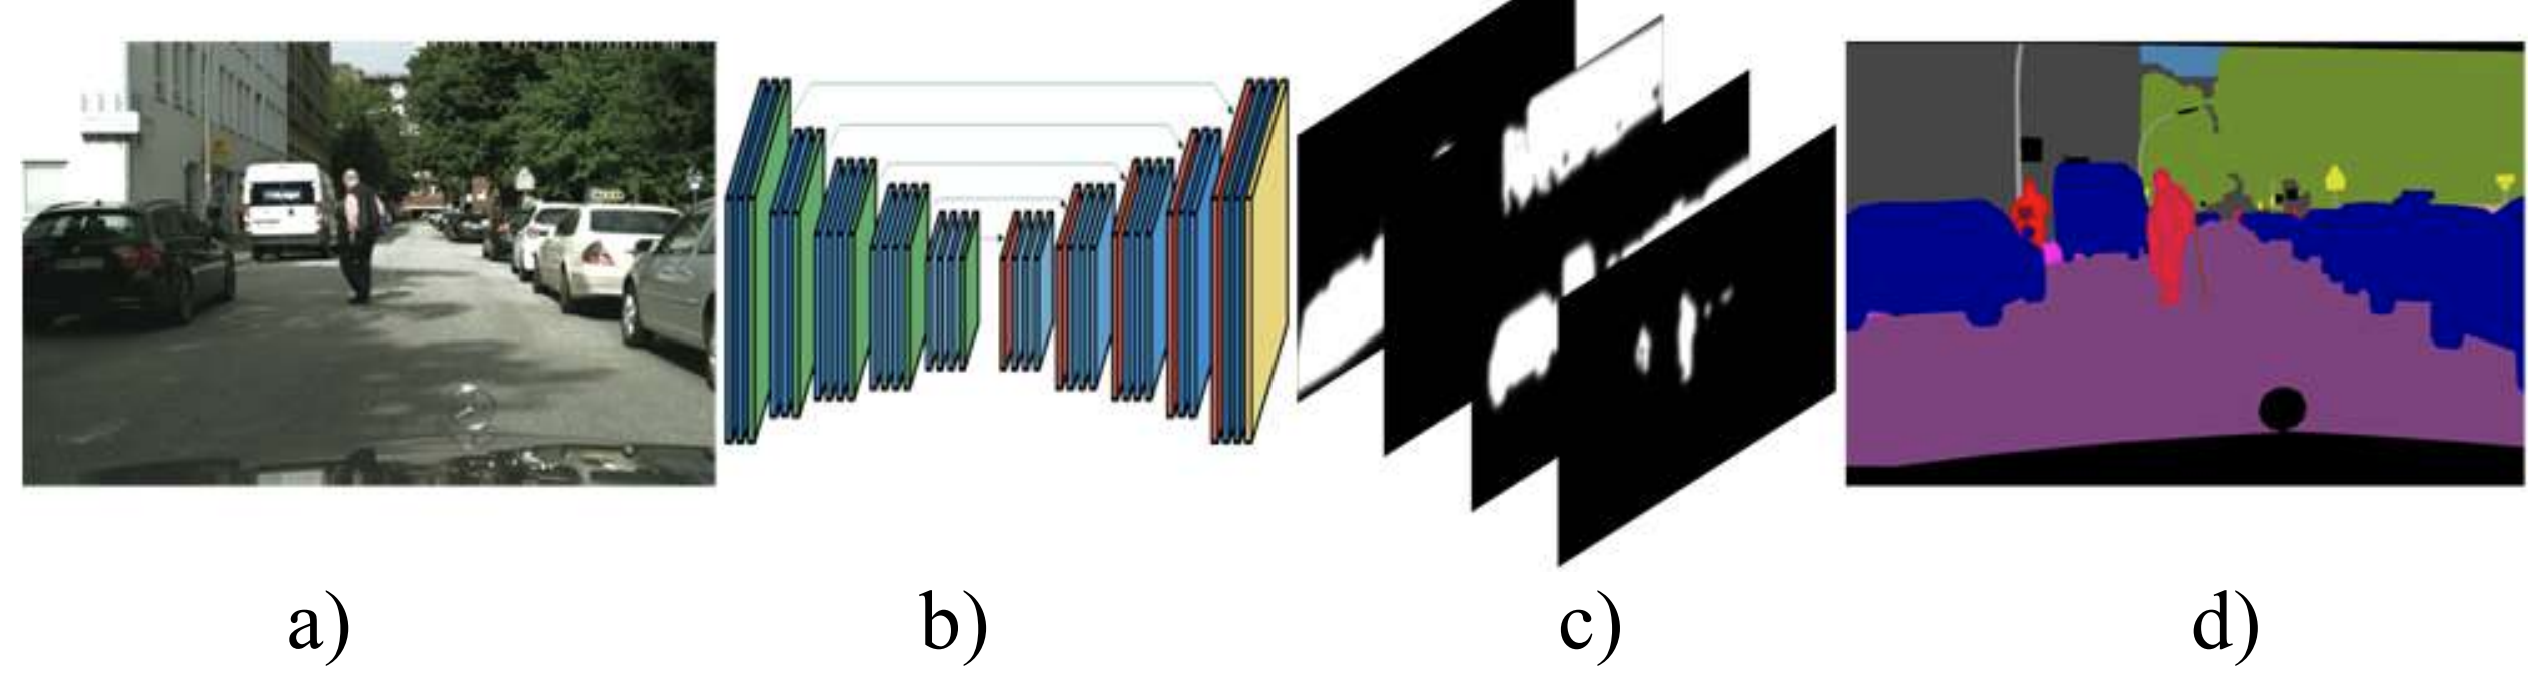
<br>
(a) Input image <br>
(b) CNN model<br>
(c) Output from the CNN model (it produces as many probability maps as the number of label classes C)<br>
(d) An argmax operation is applied to each pixel, and the class of the inference result with the highest probability is drawn<br>


---

Image source:

On Efficient Real-Time Semantic Segmentation: A Survey  (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/2206.08605



## Checking GPU Availability and the TensorFlow Version

In [ ]:
!nvidia-smi

Wed Jun  3 05:02:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
import os

print('TensorFlow version:',tf.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

# The following runs only when the library version has been changed.
if restart_flag :
    print("When a library version has been changed, the runtime is restarted automatically.")
    print("In Colab, a warning saying the session crashed for an unknown reason appears at the bottom left,")
    print("but it is safe to ignore, so please run the following code cells.")
    # We intentionally crash the session in order to restart the runtime.
    get_ipython().kernel.do_shutdown(restart=True)

TensorFlow version: 2.20.0


### Installing External Libraries and Importing Libraries

In [ ]:
!pip install -qU segmentation-models==1.0.1 # A library that makes it easy to build segmentation models

import os # os: standard library; handles OS-dependent operations (environment variables, folder creation, etc.)
import datetime # datetime: standard library; handles date-related data
import random # random: standard library; pseudo-random number generator
import numpy as np # numpy: one of the libraries for numerical computation
import pandas as pd # pandas: one of the libraries for tabular computation
from IPython.display import display # A function that can display some data more neatly than print() in environments such as Colab
import glob # glob: standard library for handling paths

import matplotlib.pylab as plt # matplotlib: one of the libraries for plotting graphs
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import seaborn as sns # seaborn: one of the libraries for plotting graphs
import tensorflow as tf # TensorFlow: one of the deep learning libraries

os.environ["SM_FRAMEWORK"] = "tf.keras" # Set the library used by segmentation_models to the Keras built into TensorFlow
import segmentation_models as sm # A library that makes it easy to build segmentation models

# For downloading the dataset from Hugging Face
from pathlib import Path, PurePosixPath
import zipfile
import shutil
import math
from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.0 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.



This time we do **not** fix the pseudo-random seed as shown below.<br>
(Because it includes operations that do not support deterministic behavior on the GPU.)
```python
def set_seed(seed=123):
    # Fix the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # External Python library: make TensorFlow's neural network behave deterministically
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # External Python library: make TensorFlow's neural network behave deterministically
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python standard library: fix the seed of random
    random.seed(seed)
    # External Python library: fix the seed of NumPy
    np.random.seed(seed)
    # External Python library: fix the seed of TensorFlow
    tf.random.set_seed(seed)
set_seed(42)
```



## Obtaining the Dataset

The dataset used in this hands-on session is obtained from a [mirror on Hugging Face](https://huggingface.co/datasets/kumuji/lost_and_found).

This dataset, "Lost and Found," was created for the purpose of detecting obstacles on the road in order to make self-driving vehicles a reality.

----
Dataset source:<br>
[arXiv] [Lost and Found: Detecting Small Road Hazards for Self-Driving Vehicles](https://arxiv.org/abs/1609.04653)

In [ ]:
REPO_ID = "kumuji/lost_and_found"
WORK_DIR = Path("./lost_and_found_hf")
EXTRACT_DIR = WORK_DIR / "selected_files"


def download_zip(filename: str) -> str:
    return hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        filename=filename,
        cache_dir=str(WORK_DIR / "hf_cache"),
    )


left_zip_path = download_zip("leftImg8bit.zip")
gt_zip_path = download_zip("gtCoarse.zip")


def _city_and_filename(member: str, anchor: str, split: str):
    parts = PurePosixPath(member).parts
    if anchor not in parts:
        return None

    i = parts.index(anchor)
    if len(parts) < i + 4:
        return None
    if parts[i + 1] != split:
        return None

    city = parts[i + 2]
    filename = parts[-1]
    return city, filename


def collect_pairs(split: str):
    with zipfile.ZipFile(left_zip_path) as left_zf, zipfile.ZipFile(gt_zip_path) as gt_zf:
        gt_index = {}

        for member in gt_zf.namelist():
            got = _city_and_filename(member, "gtCoarse", split)
            if got is None:
                continue

            city, filename = got
            if filename.endswith("_gtCoarse_labelIds.png"):
                stem = filename.removesuffix("_gtCoarse_labelIds.png")
                gt_index[(city, stem)] = member

        pairs = []

        for member in sorted(left_zf.namelist()):
            got = _city_and_filename(member, "leftImg8bit", split)
            if got is None:
                continue

            city, filename = got
            if filename.endswith("_leftImg8bit.png"):
                stem = filename.removesuffix("_leftImg8bit.png")
                label_member = gt_index.get((city, stem))

                if label_member is not None:
                    pairs.append(
                        {
                            "image_member": member,
                            "label_member": label_member,
                            "image_id": stem,
                        }
                    )

    return pairs


def percent_slice(items, start_pct: float, end_pct: float):
    n = len(items)
    start = round(n * start_pct / 100)
    end = round(n * end_pct / 100)
    return items[start:end]


def safe_extract_one(zf: zipfile.ZipFile, member: str, out_dir: Path) -> str:
    parts = [p for p in PurePosixPath(member).parts if p not in ("", ".", "..")]
    target = out_dir.joinpath(*parts)
    target.parent.mkdir(parents=True, exist_ok=True)

    if not target.exists():
        with zf.open(member) as src, open(target, "wb") as dst:
            shutil.copyfileobj(src, dst)

    return str(target)


def extract_selected(pairs):
    extracted = []

    with zipfile.ZipFile(left_zip_path) as left_zf, zipfile.ZipFile(gt_zip_path) as gt_zf:
        for p in pairs:
            image_path = safe_extract_one(left_zf, p["image_member"], EXTRACT_DIR)
            label_path = safe_extract_one(gt_zf, p["label_member"], EXTRACT_DIR)

            extracted.append(
                {
                    "image_path": image_path,
                    "label_path": label_path,
                    "image_id": p["image_id"],
                }
            )

    return extracted


def make_tf_dataset(extracted_rows):
    image_paths = [r["image_path"] for r in extracted_rows]
    label_paths = [r["label_path"] for r in extracted_rows]
    image_ids = [r["image_id"] for r in extracted_rows]

    ds = tf.data.Dataset.from_tensor_slices(
        {
            "image_path": image_paths,
            "label_path": label_paths,
            "image_id": image_ids,
        }
    )

    def load_example(x):
        image = tf.image.decode_png(tf.io.read_file(x["image_path"]), channels=3)
        label = tf.image.decode_png(tf.io.read_file(x["label_path"]), channels=1)

        image = tf.ensure_shape(image, [1024, 2048, 3])
        label = tf.ensure_shape(label, [1024, 2048, 1])

        return {
            "image_id": x["image_id"],
            "image_left": image,
            "segmentation_label": label,
        }

    return ds.map(load_example, num_parallel_calls=tf.data.AUTOTUNE)




all_train_pairs = collect_pairs("train")
all_test_pairs = collect_pairs("test")

train_pairs = percent_slice(all_train_pairs, 0, 5)
valid_pairs = percent_slice(all_train_pairs, 5, 7)
test_pairs = percent_slice(all_test_pairs, 0, 2)

train_rows = extract_selected(train_pairs)
valid_rows = extract_selected(valid_pairs)
test_rows = extract_selected(test_pairs)

dataset = {
    "train": make_tf_dataset(train_rows),
    "valid": make_tf_dataset(valid_rows),
    "test": make_tf_dataset(test_rows),
}

info = {
    "source": "huggingface:kumuji/lost_and_found",
    "features": {
        "image_id": "tf.string",
        "image_left": "tf.uint8, shape=(1024, 2048, 3)",
        "segmentation_label": "tf.uint8, shape=(1024, 2048, 1)",
    },
    "source_num_examples": {
        "train": len(all_train_pairs),
        "test": len(all_test_pairs),
    },
    "num_examples": {
        "train": len(train_rows),
        "valid": len(valid_rows),
        "test": len(test_rows),
    },
}



#######################################################
# To save time, we use only part of the dataset.
#######################################################
print(info["num_examples"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


leftImg8bit.zip:   0%|          | 0.00/5.80G [00:00<?, ?B/s]

gtCoarse.zip:   0%|          | 0.00/37.8M [00:00<?, ?B/s]

{'train': 52, 'valid': 21, 'test': 24}


In this dataset, the mask regions are originally defined as shown in the table below,<br>
but since we use only a portion of the data this time, we apply processing that simplifies them considerably.


|Label | name ID| trainID| description| category|
|----|----|----|----|----|
|’unlabeled’| 0 |255 | - | Miscellaneous |
|’ego vehicle’| 0 |255 | - | Miscellaneous|
|’rectification border’ |0 |255| -|Miscellaneous|
|’out of roi’ |0| 255| -|Miscellaneous|
|’free’ |1| 1| Free space |Counter hypotheses|
|’background’ |0| 0 | Background |Counter hypotheses|
|’01’ |2 |2 |Crate (black) |Standard objects|
|’02’ |3 |2 |Crate (black - 2x stacked)|Standard objects |
|’03’ |4| 2 |Crate (black - upright)| Standard objects|
|’04’ |5| 2| Crate (gray)| Standard objects|
|’05’ |6| 2 |Crate (gray - 2x stacked)|Standard objects|
|’06’ |7| 2| Crate (gray - upright)|Standard objects|
|’07’ |8 |2| Bumper |Random hazards|
|’08’| 9 |2| Cardboard box| Random hazards|
|’09’ |10| 2 |Crate (blue)| Random hazards|
|’10’| 11| 2 |Crate (blue - small)|Random hazards|
|’11’ |12| 2 |Crate (green)|Random hazards|
|’12’| 13| 2 |Crate (green - small)| Random hazards|
|’13’| 14| 2 |Exhaust pipe| Random hazards|
|’14’ |15 |2 |Headlight |Random hazards|
|’15’ |16| 2 |Euro pallet|Random hazards|
|’16’ |17 |2| Pylon|Random hazards|
|’17’ |18| 2 |Pylon (large)|Random hazards|
|’18’ |19 |2 |Pylon (white)|Random hazards|
|’19’ |20| 2 |Rearview mirror|Random hazards|
|’20’ |21| 2 |Tire|Random hazards|
|’29’ |30 |2| Cardboard box|Random hazards|
|’31’ |32 |2| Plastic bag (bloated)|Random hazards|
|’34’ |35 |2| Styrofoam|Random hazards|
|’21’ |22 |2 |Ball |”Emotional” hazards|
|’22’ |23 |2 |Bicycle|”Emotional” hazards|
|’23’ |24 |2 |Dog (black)|”Emotional” hazards|
|’24’ |25 |2 |Dog (white)|”Emotional” hazards|
|’25’ |26 |2 |Kid Dummy|”Emotional” hazards|
|’26’ |27 |2 |Bobby car (gray)|”Emotional” hazards|
|’27’ |28 |2 |Bobby car (red)|”Emotional” hazards|
|’28’ |29 |2 |Bobby car (yellow)|”Emotional” hazards|
|’30’ |31 |0 |Marker pole (lying) |Random non-hazards|
|’32’ |33 |0 |Post (red - lying)|Random non-hazards|
|’33’ |34 |0 |Post stand|Random non-hazards|
|’35’ |36 |0 |Timber (small)|Random non-hazards|
|’36’ |37 |0 |Timber (squared)|Random non-hazards|
|’37’ |38 |0 |Wheel cap|Random non-hazards|
|’38’ |39 |0 |Wood (thin)|Random non-hazards|
|’39’ |40 |2 |Kid (walking) |Humans|
|’40’ |41 |2 |Kid (on a bobby car)|Humans|
|’41’ |42 |2 |Kid (on a small bobby car)|Humans|
|’42’ |43 |2 |Kid (crawling)|Humans|


## Adjusting and Generating the Input Data
To save time, in this hands-on session we simplify the ground-truth mask regions as shown in the table below.

|Numeric label of the mask region | Category name of the mask region|
|----|----|
|0 | Background |
|1 | Drivable area |
|2 | Road hazard |
|3 | Other |

Also, the original image size is 1024 (height) x 2048 (width), but this is too large to train on Colab, so we downscale the images.

In [ ]:

# Image size to use
IMG_SIZE_WIDTH = 256 # Original image is 2048
IMG_SIZE_HEIGHT = 128 # Original image is 1024

TRAIN_LENGTH = dataset['train'].cardinality().numpy()
VALID_LENGTH = dataset['valid'].cardinality().numpy()
TEST_LENGTH = dataset['test'].cardinality().numpy()

BATCH_SIZE = 8
BUFFER_SIZE = 10
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE
VALIDATION_STEPS = VALID_LENGTH // BATCH_SIZE

# Define the correspondence between numeric labels and category names
mask_label_to_category_name = {
    0 : 'Background',
    1 : 'Drivable area',
    2 : 'Road hazard',
    3 : 'Other'
}

@tf.function
def mapping(x):
    ###
    # Adjust the ground-truth labels for simplification
    ###

    # Standard objects,
    # Random hazards (foreign objects that are dangerous to drive into),
    # Random non-hazards (foreign objects that are not dangerous to drive into),
    # Emotional hazards (objects that are psychologically dangerous, e.g., ball/dog/cat),
    # humans
    #  -> treat all of these collectively as a "Road hazard"
    x = tf.where( ( ( x >= 2 ) & ( x <= 43) ), 2, x)

    # miscellaneous (Other)
    x = tf.where( ( x>=255 )&( x<=255 ), 3, x)

    return x

def normalize(input_image, input_mask):

    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32)

    input_mask = tf.map_fn(fn=mapping, elems=input_mask, fn_output_signature=tf.int32)

    input_mask = tf.reshape(tensor = tf.one_hot(tf.cast(input_mask, tf.int32), depth=len(mask_label_to_category_name), axis=3), \
                            shape = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH, len(mask_label_to_category_name)))

    return input_image, input_mask


def load_image(datapoint):

    input_image = tf.image.resize(images = datapoint['image_left'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                method=tf.image.ResizeMethod.BILINEAR
                                )


    input_mask = tf.image.resize(images = datapoint['segmentation_label'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                antialias=False, # Has no effect for NEAREST_NEIGHBOR
                                # A deterministic GPU implementation of ResizeNearestNeighborGrad is not currently available.
                                # This interpolation method does not support deterministic GPU behavior, but we use it to interpolate the mask regions.
                                # Other interpolation methods average neighboring pixel values and so on, which changes the mask-region values to unintended values, making them unsuitable.
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
                                #method=tf.image.ResizeMethod.BILINEAR #(interpolation unsuitable for masks)
                                #method=tf.image.ResizeMethod.BICUBIC #(interpolation unsuitable for masks)
                                #method=tf.image.ResizeMethod.AREA #(interpolation unsuitable for masks)
                                )

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask



train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_images = dataset['valid'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

print(f'Input image size (width): {IMG_SIZE_WIDTH}')
print(f'Input image size (height): {IMG_SIZE_HEIGHT}')

print(f'Number of training samples: {TRAIN_LENGTH}')
print(f'Number of validation samples: {VALID_LENGTH}')
print(f'Number of test samples: {TEST_LENGTH}')


Input image size (width): 256
Input image size (height): 128
Number of training samples: 52
Number of validation samples: 21
Number of test samples: 24


We apply data augmentation that randomly flips images horizontally, only to the training dataset.

We then visualize a sample image processed as above together with the corresponding mask from the dataset.

(128, 256, 4)
[0 1 2]


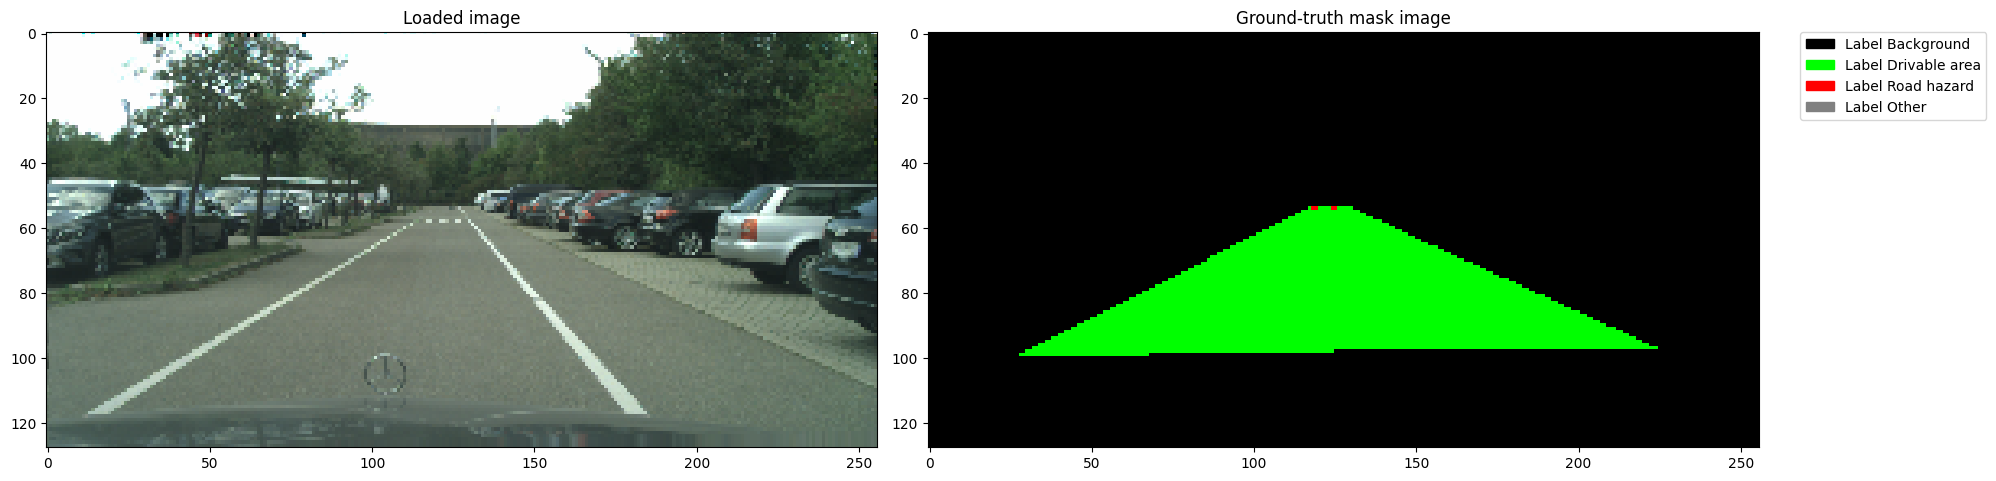

(128, 256, 4)
[0 1 2]


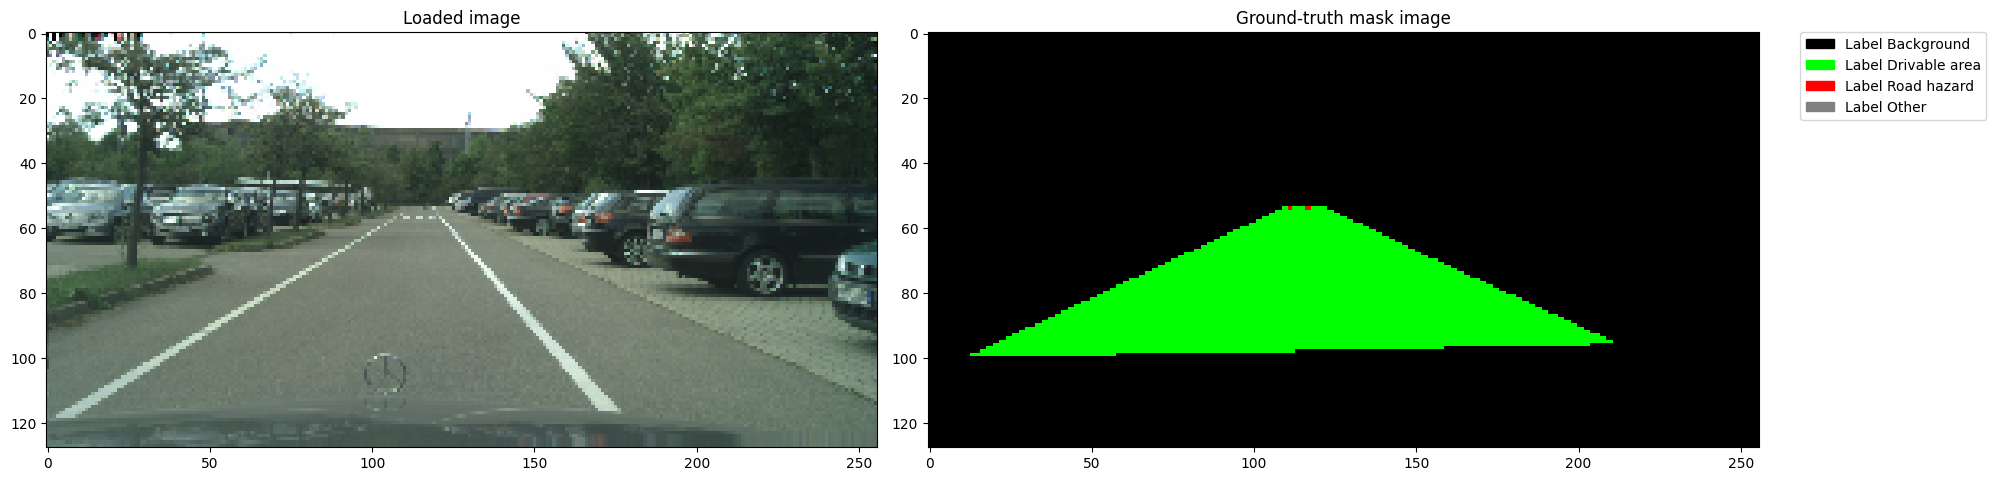

(128, 256, 4)
[0 1 2]


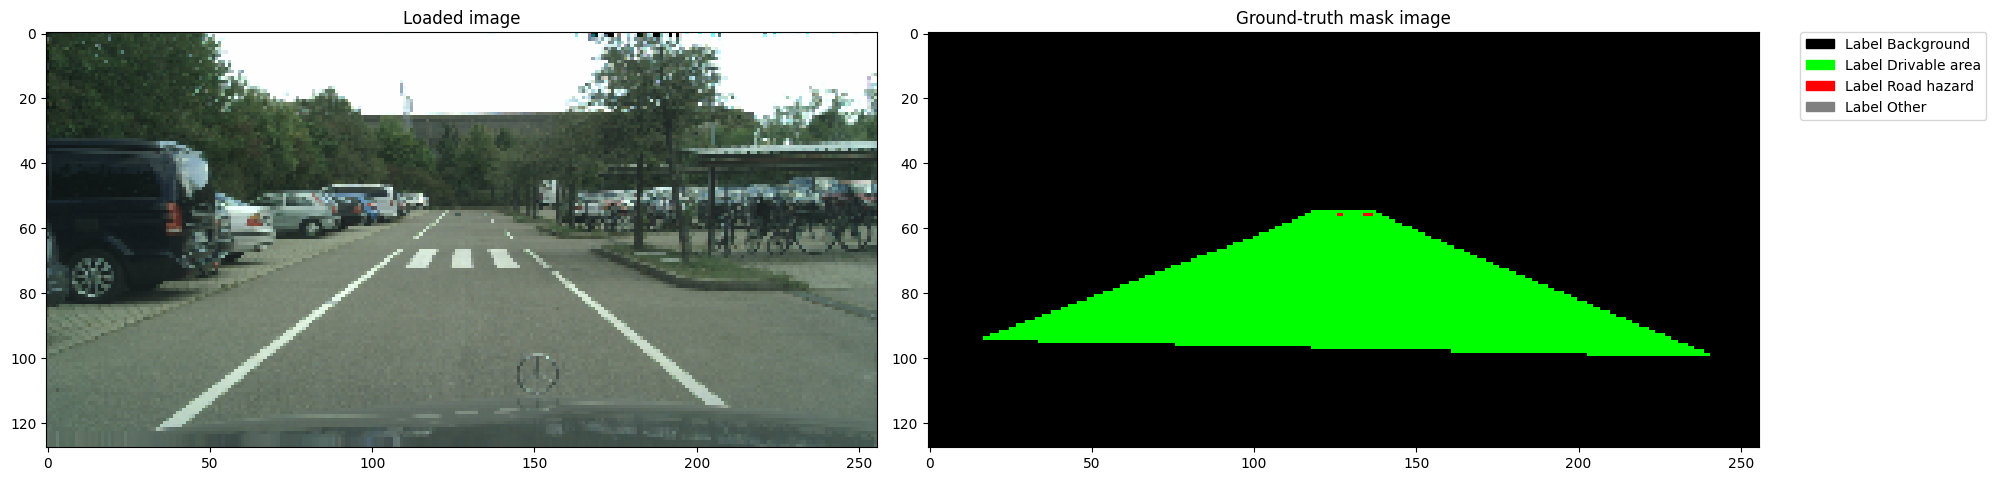

In [ ]:
# Define data augmentation that randomly flips images horizontally.
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

# Apply data augmentation only to the training dataset.
train_dataset = (
    train_images
    #.cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

# Do not apply data augmentation to the validation or test datasets.
valid_dataset = valid_images.batch(BATCH_SIZE).repeat()
test_dataset = test_images.batch(BATCH_SIZE)


# Below is the code for drawing sample images

colors = ['black', 'lime', 'red', 'gray']
cmap = ListedColormap(colors, name="custom")
cmap.set_bad('yellow') # When an invalid value is produced
values = range(len(mask_label_to_category_name))

for images, masks in train_dataset.take(1):
    # Draw the first 3 images from one batch
    for n in range(3):

        sample_image, sample_mask = images[n], masks[n]

        print(sample_mask.numpy().shape)

        sample_mask = tf.math.argmax(sample_mask, axis=-1)[..., tf.newaxis]

        fig, axes = plt.subplots(1,2, figsize=(20,5))
        axes[0].imshow(sample_image)
        axes[0].set_title('Loaded image')

        print(np.unique(sample_mask.numpy()))

        axes[1].imshow(sample_mask, interpolation = 'none', \
                            cmap = cmap, vmin = np.min(values), vmax = np.max(values))
        axes[1].set_title('Ground-truth mask image')

        patches = [ mpatches.Patch(color=colors[i], label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
        plt.tight_layout()
        plt.show()

## Building the Segmentation Model

The model we use is a modified [U-Net](https://arxiv.org/abs/1505.04597).

U-Net consists of an encoder (downsampler) and a decoder (upsampler).
The convolution operations in the encoder extract features from the input image. In the decoder, the feature maps extracted by the encoder are enlarged back to the same size as the input image through transposed-convolution operations.

Here, we use a pre-trained model as the encoder in order to shorten the training time.

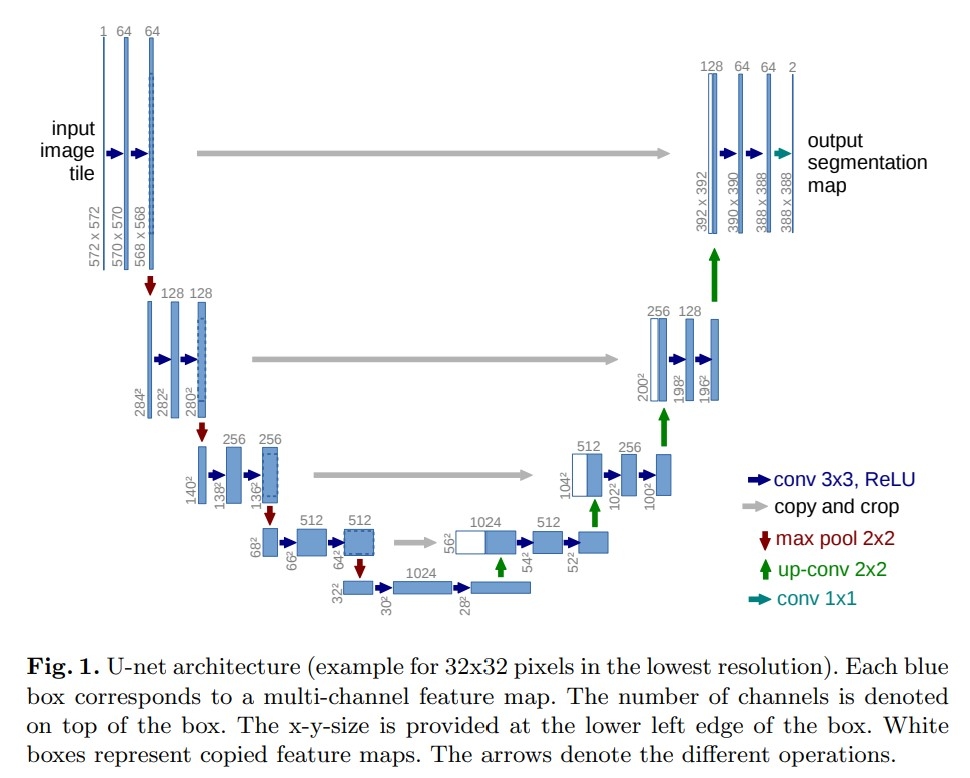

---

Image source:

U-Net: Convolutional Networks for Biomedical Image Segmentation (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/1505.04597


Before training the model, let's look at what the model outputs.

In [ ]:
# Define functions for drawing.
# This code cell produces no output when run, but be sure to run it.

def create_mask(pred_mask, n=0):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[n]


def show_predictions(dataset, num=1):

    colors = ['black', 'lime', 'red', 'gray']
    cmap = ListedColormap(colors, name="custom")
    cmap.set_bad('yellow') # When an invalid value is produced
    values = range(len(mask_label_to_category_name))

    for image, true_mask in dataset.take(1):
        for n in range(num):

            fig, axes = plt.subplots(1, 3, figsize=(20,5))
            axes[0].imshow(image[n])
            axes[0].set_title('Loaded image')

            axes[1].imshow(create_mask(true_mask, n=n), interpolation='none', \
                          cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[1].set_title('Ground-truth mask image')

            predict_mask = create_mask( model.predict(image), n=n )
            axes[2].imshow(predict_mask, interpolation='none', \
                                cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[2].set_title('Region estimated by the model')

            print(np.unique(predict_mask.numpy().ravel()))

            patches = [ mpatches.Patch(color=colors[i], \
                                        label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]

            plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
            plt.tight_layout()
            plt.show()

Let's build the model and look at its output in the untrained state.

/usr/local/lib/python3.12/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
[0 2 3]


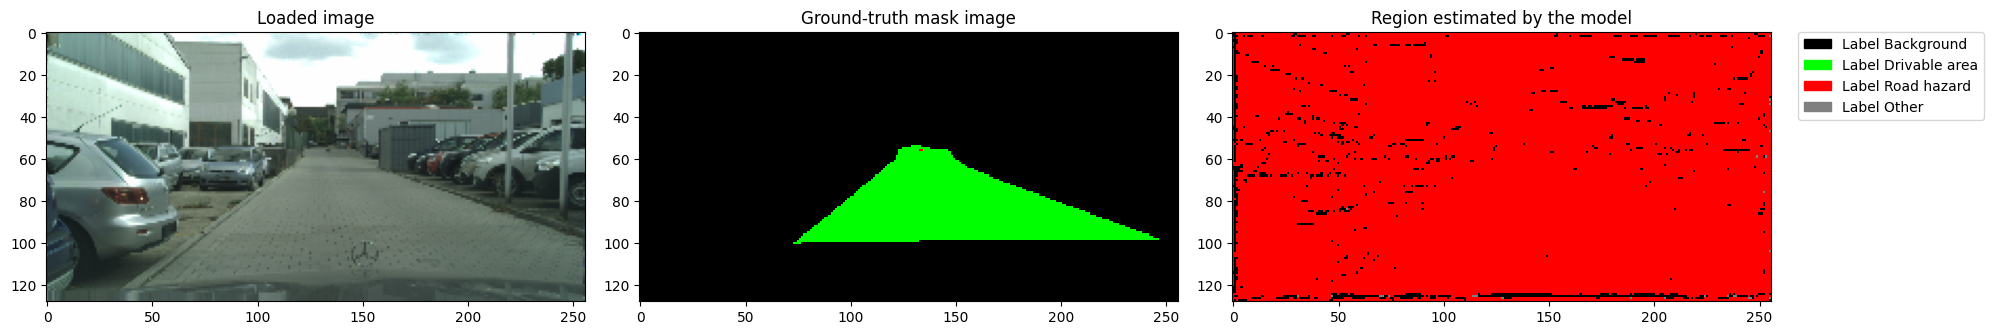

In [ ]:
tf.keras.backend.set_image_data_format('channels_last')

model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    'Adam',
    loss=sm.losses.dice_loss,
    metrics=[sm.metrics.iou_score],
)

# Using the drawing function defined in the cell above, check what the untrained model outputs.
show_predictions(test_dataset)

You can clearly see that the untrained model is not able to perform inference well.

From here, let's train the model and watch how it changes.

Let's briefly print the structure of the model we built.

In [ ]:
# This outputs to a PNG file
tf.keras.utils.plot_model(model, to_file='unet_model.png', show_shapes=True)

# This outputs below
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ Conv1_pad[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis

 Total params: 8,047,876 (30.70 MB)

 Trainable params: 8,011,780 (30.56 MB)

 Non-trainable params: 36,096 (141.00 KB)

## Training the Model

This time, we create a ```DisplayCallback``` to monitor how the model improves during training.

/usr/local/lib/python3.12/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
[0 1 2 3]


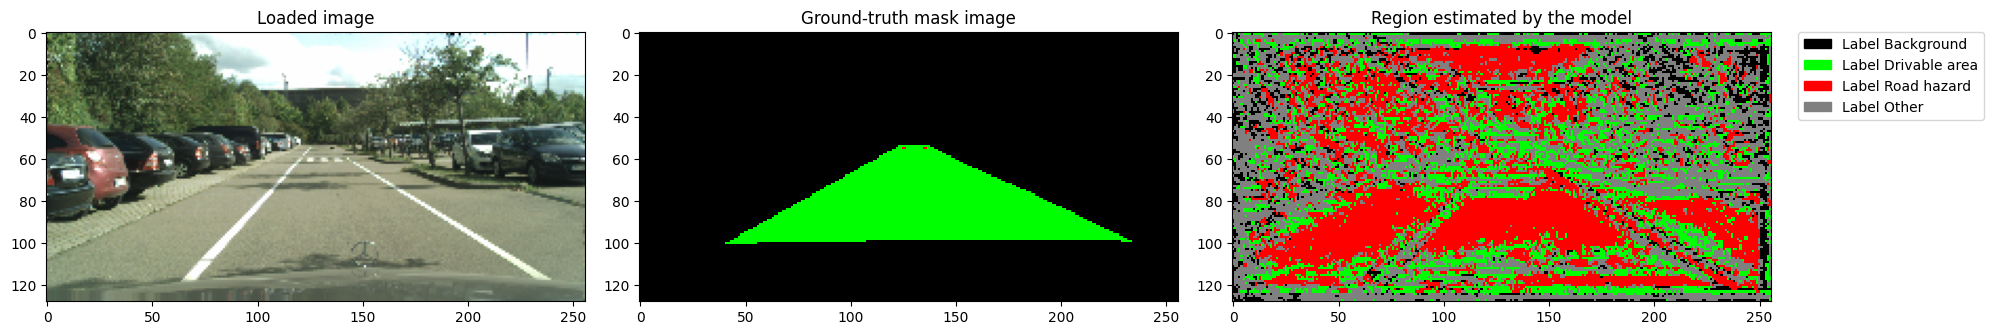


Sample Prediction after epoch 1

6/6 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - iou_score: 0.1136 - loss: 3.4799 - val_iou_score: 0.0734 - val_loss: 3.6293
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 50s 612ms/step - iou_score: 0.1358 - loss: 3.3788 - val_iou_score: 0.0730 - val_loss: 3.5833
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 904ms/step - iou_score: 0.1626 - loss: 3.2597 - val_iou_score: 0.0711 - val_loss: 3.5465
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.1940 - loss: 3.1247 - val_iou_score: 0.0648 - val_loss: 3.5764
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 886ms/step - iou_score: 0.2201 - loss: 3.0154 - val_iou_score: 0.0620 - val_loss: 3.5912
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 960ms/step - iou_score: 0.2425 - loss: 2.9255 - val_iou_score: 0.0661 - val_loss: 3.5724
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 748ms/step - iou_score: 0.2636 - loss: 2.8461 - val_iou_score: 0.0762 - val_loss: 3.5268
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.2813 - loss: 2.7

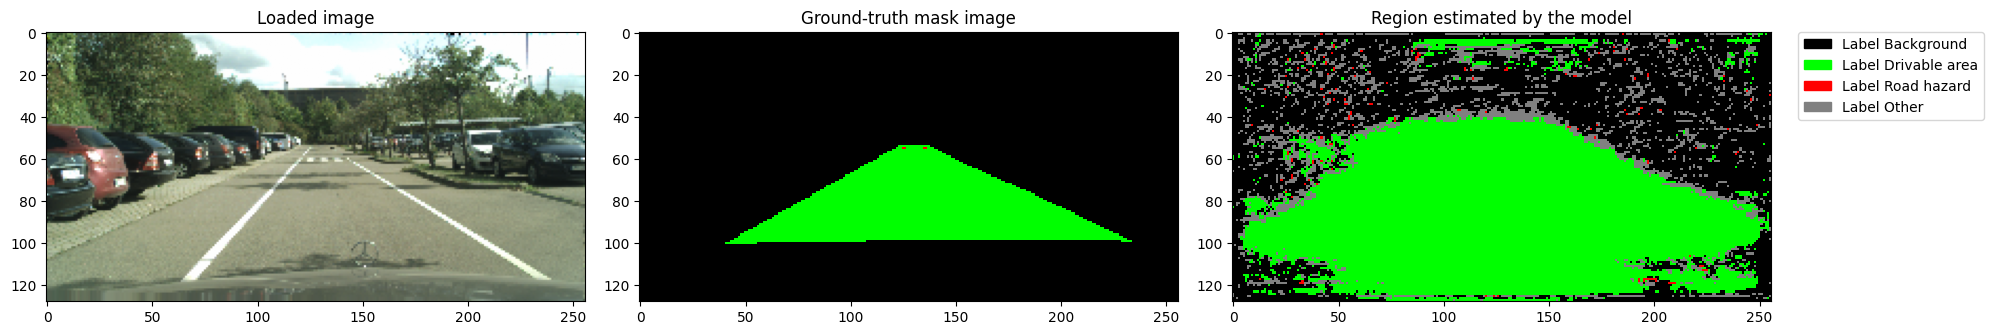


Sample Prediction after epoch 11

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.3177 - loss: 2.6503 - val_iou_score: 0.1311 - val_loss: 3.2918
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - iou_score: 0.3243 - loss: 2.6185 - val_iou_score: 0.1506 - val_loss: 3.2130
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - iou_score: 0.3375 - loss: 2.5843 - val_iou_score: 0.1676 - val_loss: 3.1468
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 685ms/step - iou_score: 0.3458 - loss: 2.5517 - val_iou_score: 0.1845 - val_loss: 3.0819
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.3579 - loss: 2.5188 - val_iou_score: 0.2022 - val_loss: 3.0154
Epoch 16/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 507ms/step - iou_score: 0.3649 - loss: 2.4914 - val_iou_score: 0.2202 - val_loss: 2.9492
Epoch 17/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 794ms/step - iou_score: 0.3733 - loss: 2.4670 - val_iou_score: 0.2373 - val_loss: 2.8879
Epoch 18/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 989ms/step - iou_score: 0.3784 -

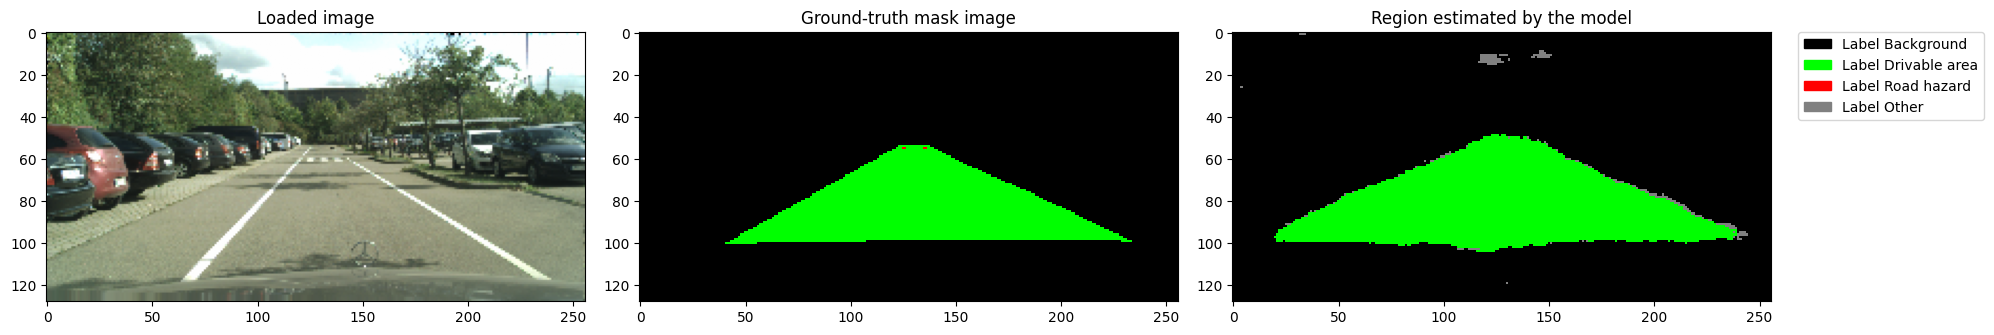


Sample Prediction after epoch 21

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.3985 - loss: 2.3873 - val_iou_score: 0.2908 - val_loss: 2.7015
Epoch 22/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - iou_score: 0.4032 - loss: 2.3672 - val_iou_score: 0.2908 - val_loss: 2.7010
Epoch 23/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 661ms/step - iou_score: 0.4106 - loss: 2.3424 - val_iou_score: 0.3153 - val_loss: 2.6191
Epoch 24/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step - iou_score: 0.4139 - loss: 2.3301 - val_iou_score: 0.3125 - val_loss: 2.6276
Epoch 25/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 879ms/step - iou_score: 0.4179 - loss: 2.3139 - val_iou_score: 0.3157 - val_loss: 2.6172
Epoch 26/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.4198 - loss: 2.3068 - val_iou_score: 0.3346 - val_loss: 2.5573
Epoch 27/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 881ms/step - iou_score: 0.4278 - loss: 2.2794 - val_iou_score: 0.3513 - val_loss: 2.5034
Epoch 28/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.4269 - los

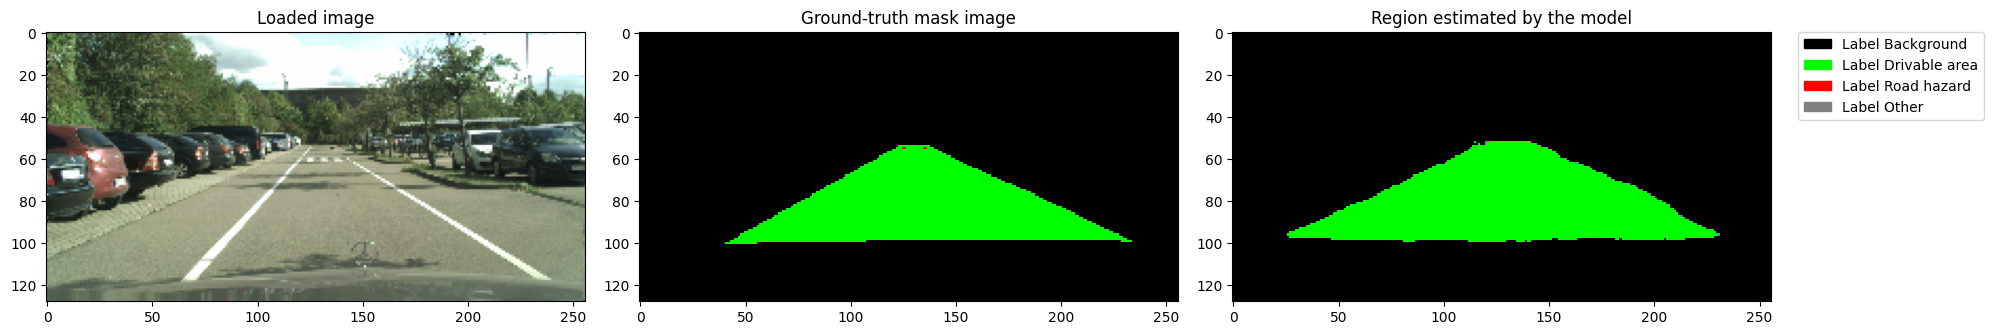


Sample Prediction after epoch 31

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - iou_score: 0.4362 - loss: 2.2284 - val_iou_score: 0.3615 - val_loss: 2.4780
Epoch 32/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - iou_score: 0.4380 - loss: 2.2240 - val_iou_score: 0.3584 - val_loss: 2.4792
Epoch 33/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 561ms/step - iou_score: 0.4475 - loss: 2.1742 - val_iou_score: 0.3725 - val_loss: 2.4332
Epoch 34/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - iou_score: 0.4496 - loss: 2.1582 - val_iou_score: 0.3724 - val_loss: 2.4355
Epoch 35/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - iou_score: 0.4563 - loss: 2.1333 - val_iou_score: 0.3772 - val_loss: 2.4101
Epoch 36/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 792ms/step - iou_score: 0.4622 - loss: 2.1014 - val_iou_score: 0.3896 - val_loss: 2.3722
Epoch 37/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 820ms/step - iou_score: 0.4544 - loss: 2.1292 - val_iou_score: 0.3867 - val_loss: 2.3732
Epoch 38/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step - iou_score: 0.4720 -

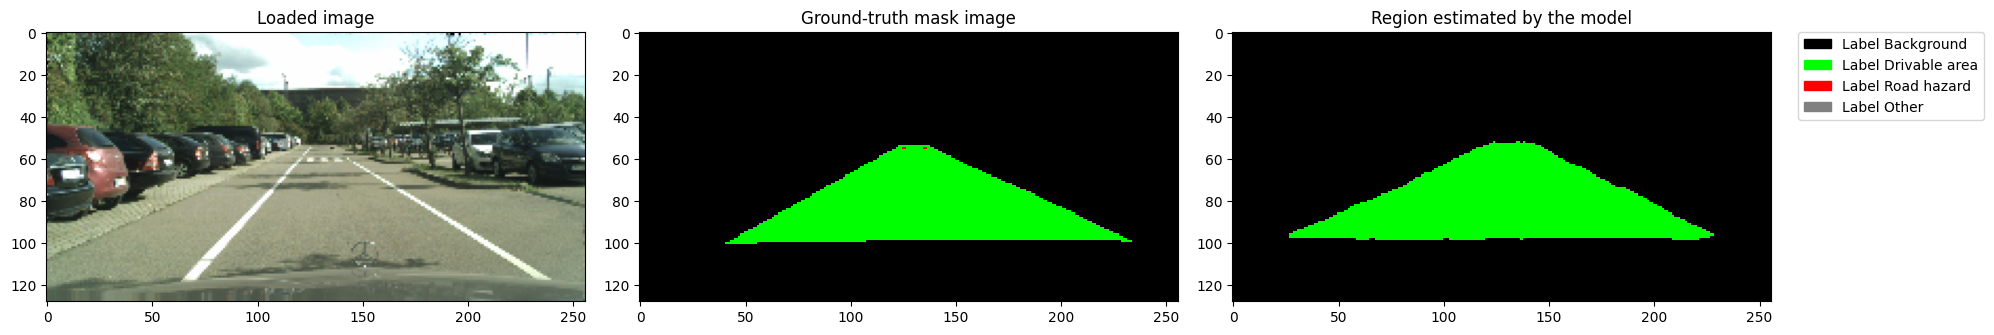


Sample Prediction after epoch 41

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.4863 - loss: 1.9943 - val_iou_score: 0.3942 - val_loss: 2.3682
Epoch 42/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 894ms/step - iou_score: 0.4901 - loss: 1.9337 - val_iou_score: 0.3986 - val_loss: 2.3505
Epoch 43/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - iou_score: 0.4927 - loss: 1.9346 - val_iou_score: 0.3979 - val_loss: 2.3578
Epoch 44/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.4975 - loss: 1.9287 - val_iou_score: 0.3989 - val_loss: 2.3442
Epoch 45/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - iou_score: 0.4985 - loss: 1.9047 - val_iou_score: 0.4012 - val_loss: 2.3385
Epoch 46/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 711ms/step - iou_score: 0.5076 - loss: 1.8826 - val_iou_score: 0.4017 - val_loss: 2.3334
Epoch 47/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.5024 - loss: 1.8917 - val_iou_score: 0.4061 - val_loss: 2.3149
Epoch 48/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 957ms/step - iou_score: 0.5273 - lo

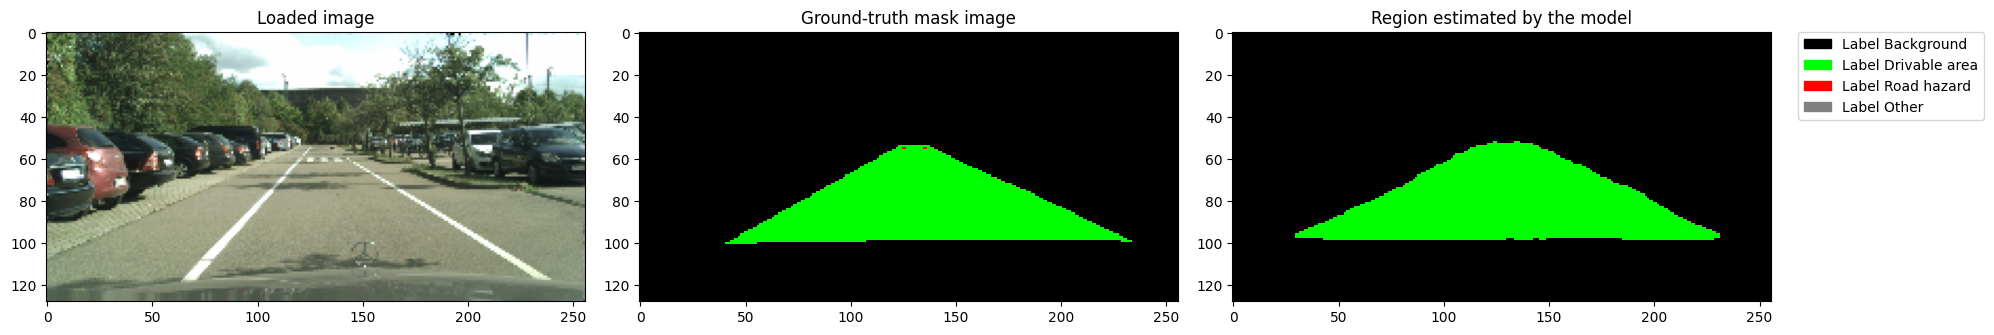


Sample Prediction after epoch 51

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.5186 - loss: 1.8135 - val_iou_score: 0.3974 - val_loss: 2.3466
Epoch 52/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 637ms/step - iou_score: 0.5358 - loss: 1.7734 - val_iou_score: 0.4069 - val_loss: 2.3111
Epoch 53/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 765ms/step - iou_score: 0.5511 - loss: 1.7137 - val_iou_score: 0.4056 - val_loss: 2.3205
Epoch 54/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 901ms/step - iou_score: 0.5466 - loss: 1.6996 - val_iou_score: 0.4061 - val_loss: 2.3195
Epoch 55/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.5421 - loss: 1.7030 - val_iou_score: 0.4019 - val_loss: 2.3368
Epoch 56/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 651ms/step - iou_score: 0.5635 - loss: 1.6127 - val_iou_score: 0.4133 - val_loss: 2.2887
Epoch 57/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 915ms/step - iou_score: 0.5670 - loss: 1.6150 - val_iou_score: 0.4085 - val_loss: 2.3092
Epoch 58/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.5387 - lo

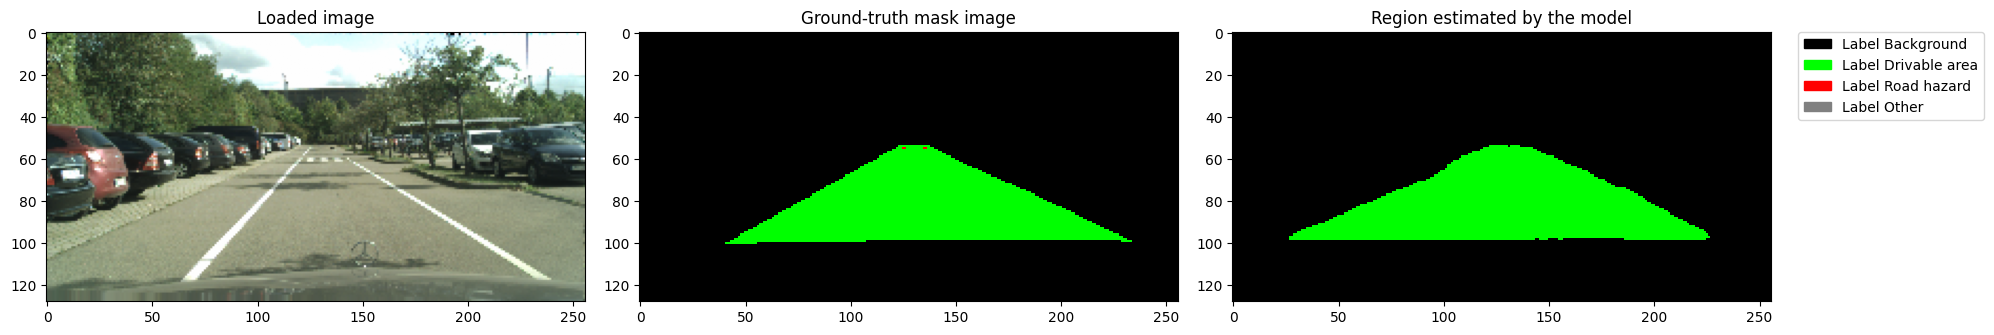


Sample Prediction after epoch 61

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.5647 - loss: 1.6318 - val_iou_score: 0.4228 - val_loss: 2.2520
Epoch 62/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 824ms/step - iou_score: 0.5994 - loss: 1.5207 - val_iou_score: 0.4332 - val_loss: 2.1834
Epoch 63/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - iou_score: 0.5835 - loss: 1.5216 - val_iou_score: 0.4232 - val_loss: 2.2460
Epoch 64/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 502ms/step - iou_score: 0.6001 - loss: 1.5097 - val_iou_score: 0.4213 - val_loss: 2.2566
Epoch 65/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.5751 - loss: 1.5796 - val_iou_score: 0.4159 - val_loss: 2.2858
Epoch 66/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 892ms/step - iou_score: 0.5792 - loss: 1.5521 - val_iou_score: 0.4215 - val_loss: 2.2617
Epoch 67/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 845ms/step - iou_score: 0.6202 - loss: 1.4582 - val_iou_score: 0.4176 - val_loss: 2.2737
Epoch 68/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6005 - lo

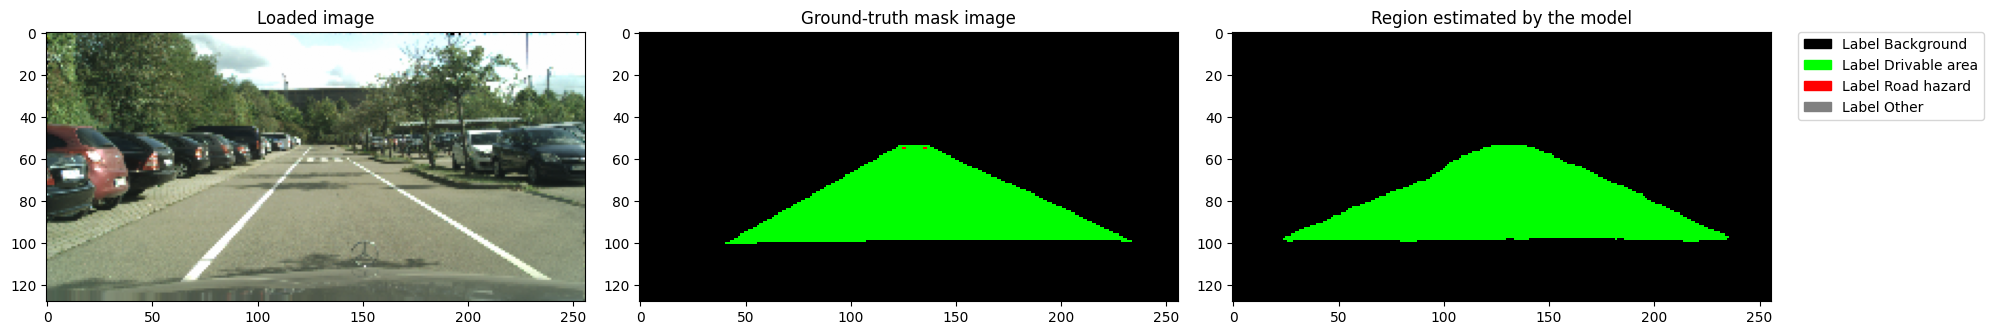


Sample Prediction after epoch 71

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.6163 - loss: 1.4514 - val_iou_score: 0.4282 - val_loss: 2.2288
Epoch 72/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 495ms/step - iou_score: 0.6303 - loss: 1.4050 - val_iou_score: 0.4350 - val_loss: 2.2124
Epoch 73/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.6010 - loss: 1.5337 - val_iou_score: 0.4420 - val_loss: 2.1672
Epoch 74/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 932ms/step - iou_score: 0.5919 - loss: 1.5370 - val_iou_score: 0.4256 - val_loss: 2.2458
Epoch 75/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 872ms/step - iou_score: 0.6083 - loss: 1.4615 - val_iou_score: 0.4415 - val_loss: 2.1783
Epoch 76/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6077 - loss: 1.4868 - val_iou_score: 0.4283 - val_loss: 2.2292
Epoch 77/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 652ms/step - iou_score: 0.6544 - loss: 1.3306 - val_iou_score: 0.4322 - val_loss: 2.2258
Epoch 78/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6354 - loss:

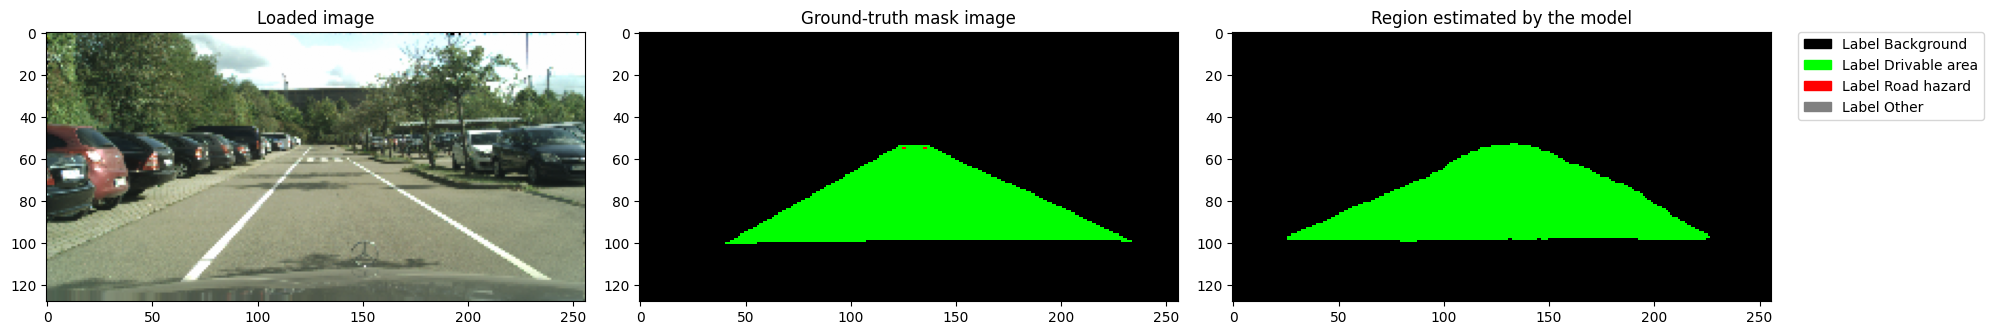


Sample Prediction after epoch 81

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - iou_score: 0.6328 - loss: 1.3737 - val_iou_score: 0.4257 - val_loss: 2.2426
Epoch 82/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - iou_score: 0.6094 - loss: 1.4358 - val_iou_score: 0.4380 - val_loss: 2.2050
Epoch 83/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6397 - loss: 1.3511 - val_iou_score: 0.4316 - val_loss: 2.2300
Epoch 84/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 540ms/step - iou_score: 0.6488 - loss: 1.3349 - val_iou_score: 0.4442 - val_loss: 2.1665
Epoch 85/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 563ms/step - iou_score: 0.6553 - loss: 1.3228 - val_iou_score: 0.4389 - val_loss: 2.1939
Epoch 86/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.6609 - loss: 1.3057 - val_iou_score: 0.4410 - val_loss: 2.1737
Epoch 87/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - iou_score: 0.6392 - loss: 1.3820 - val_iou_score: 0.4345 - val_loss: 2.2063
Epoch 88/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 870ms/step - iou_score: 0.6572 - loss:

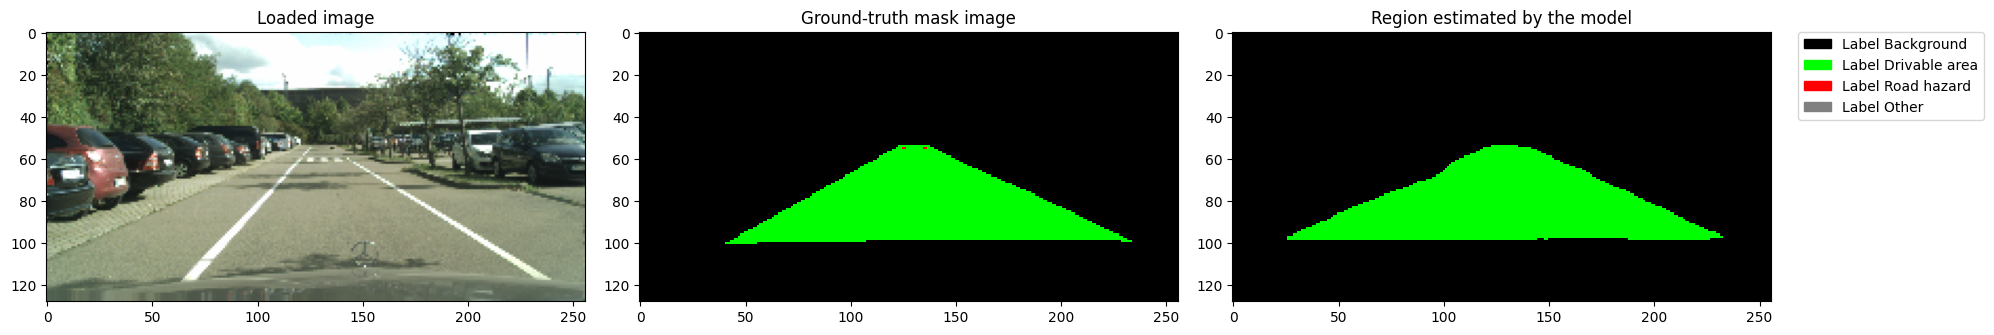


Sample Prediction after epoch 91

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - iou_score: 0.6400 - loss: 1.3274 - val_iou_score: 0.4629 - val_loss: 2.0847
Epoch 92/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - iou_score: 0.6623 - loss: 1.2892 - val_iou_score: 0.4435 - val_loss: 2.1793
Epoch 93/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.6820 - loss: 1.2552 - val_iou_score: 0.4462 - val_loss: 2.1518
Epoch 94/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 986ms/step - iou_score: 0.6654 - loss: 1.2839 - val_iou_score: 0.4487 - val_loss: 2.1576
Epoch 95/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 888ms/step - iou_score: 0.6789 - loss: 1.2600 - val_iou_score: 0.4595 - val_loss: 2.1090
Epoch 96/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - iou_score: 0.6690 - loss: 1.2814 - val_iou_score: 0.4481 - val_loss: 2.1617
Epoch 97/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 867ms/step - iou_score: 0.6568 - loss: 1.3022 - val_iou_score: 0.4675 - val_loss: 2.0779
Epoch 98/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 669ms/step - iou_score: 0.6821 - los

In [ ]:
# * This code cell takes about 15 minutes to finish running.

# Code for outputting inference images during training
class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, validation_dataset):
        super().__init__()
        self.validation_data = validation_dataset

    def on_epoch_end(self, epoch, logs):
        # Output an inference image every 10 epochs
        if (epoch % 10 == 0) :
            show_predictions(self.validation_data)
            print('\nSample Prediction after epoch {}\n'.format(epoch+1))

###
#  Focal Tversky Loss (multi-class extended version)
#  A loss function that is relatively robust to data with imbalanced mask-region areas
###

## 100 epochs (run time / 14 min)

def class_tversky(y_true: tf.Tensor, y_pred: tf.Tensor):
    smooth = 1

    true_pos = tf.reduce_sum(y_true * y_pred, axis=(0, 1, 2))
    false_neg = tf.reduce_sum(y_true * (1-y_pred), axis=(0, 1, 2))
    false_pos = tf.reduce_sum((1-y_true) * y_pred, axis=(0, 1, 2))
    alpha = 0.7
    return (true_pos + smooth) / (true_pos + alpha * false_neg + (1-alpha) * false_pos + smooth)

def focal_tversky_loss(y_true: tf.Tensor, y_pred: tf.Tensor):
    pt_1 = class_tversky(y_true, y_pred)
    gamma = 0.75
    return tf.reduce_sum( (1-pt_1)**gamma )


tf.keras.backend.set_image_data_format('channels_last')


model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    tf.keras.optimizers.Adam(1.0e-4),
    loss=focal_tversky_loss,
    metrics=[sm.metrics.iou_score],
)

# Preparation for creating a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))
callbacks.append(DisplayCallback(valid_dataset))

# Train the model
model_history = model.fit(
   x = train_dataset,
   epochs = 100,
   validation_data = valid_dataset,
   steps_per_epoch = STEPS_PER_EPOCH,
   validation_steps = VALIDATION_STEPS,
   callbacks = callbacks
)

## Evaluating the Model

### Inference with the Trained Model

In [ ]:
train_loss, train_iou = model.evaluate(train_dataset, steps = (TRAIN_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (train): {:.4}".format(train_loss))
print("iou (train): {:.4}".format(train_iou))

print()

test_loss, test_iou = model.evaluate(test_dataset, steps = (TEST_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (test): {:.4}".format(test_loss))
print("iou (test): {:.4}".format(test_iou))

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - iou_score: 0.5481 - loss: 1.7749
loss (train): 1.775
iou (train): 0.5481

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - iou_score: 0.4484 - loss: 2.1641
loss (test): 2.164
iou (test): 0.4484


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### Transition of the Loss and the Evaluation Metric

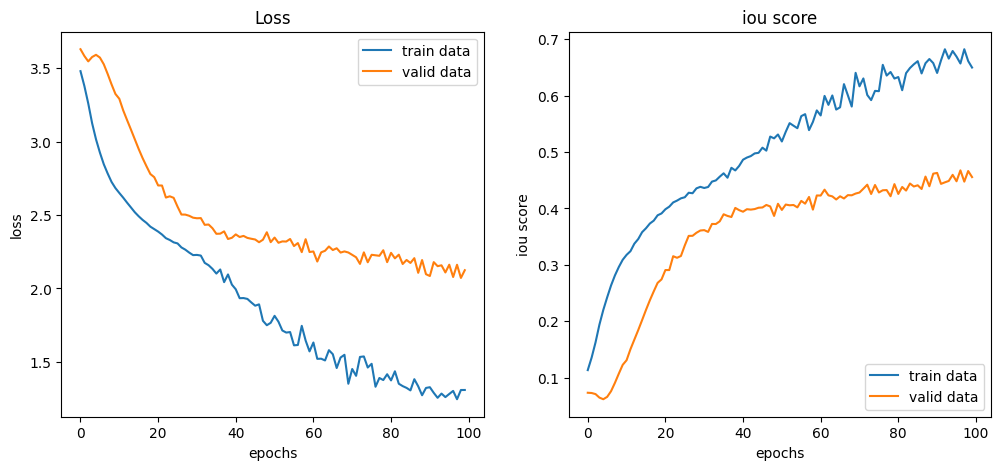

In [ ]:
log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["iou_score"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_iou_score"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("iou score")
axes[1].legend(loc="lower right")
axes[1].set_title("iou score")

plt.show()

### Examples of Estimation by the Trained Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
[0 1 2]


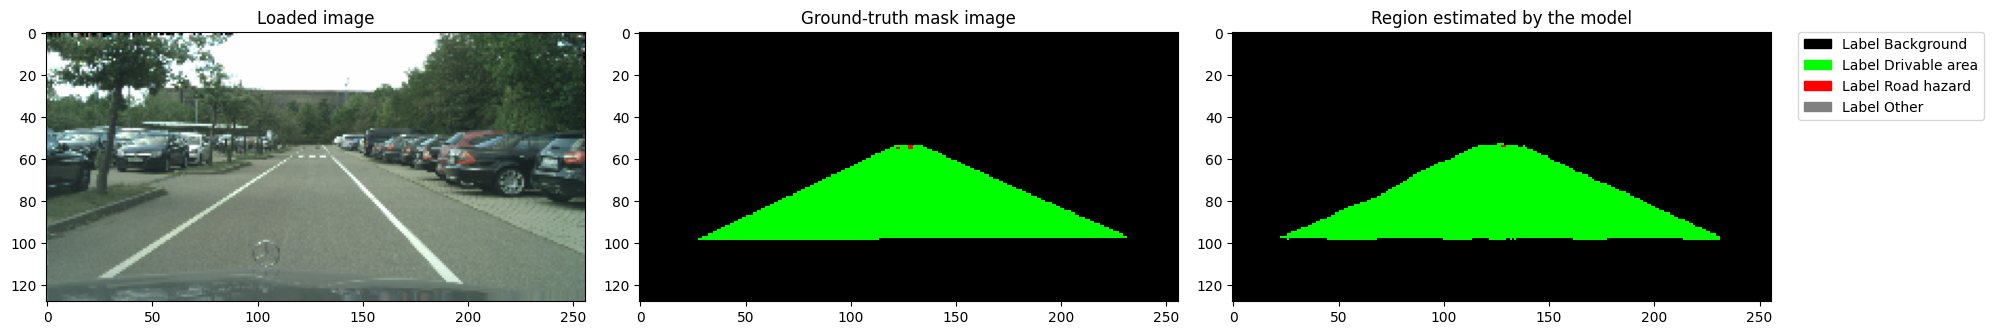

In [ ]:
# Training dataset
show_predictions(train_dataset, num=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[0 1]


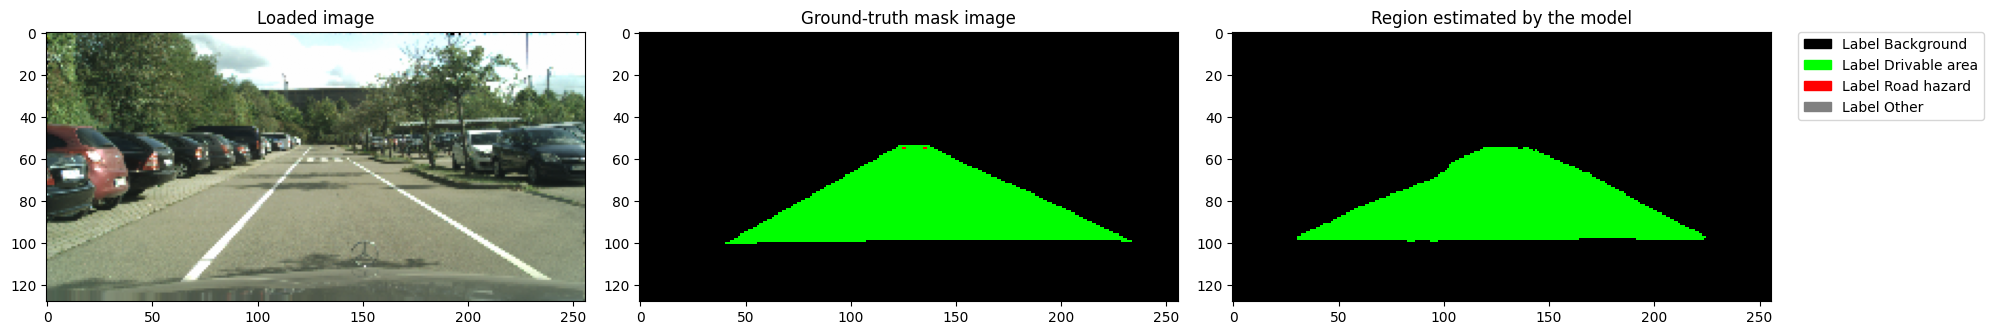

In [ ]:
# Validation dataset
show_predictions(valid_dataset, num=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
[0 1]


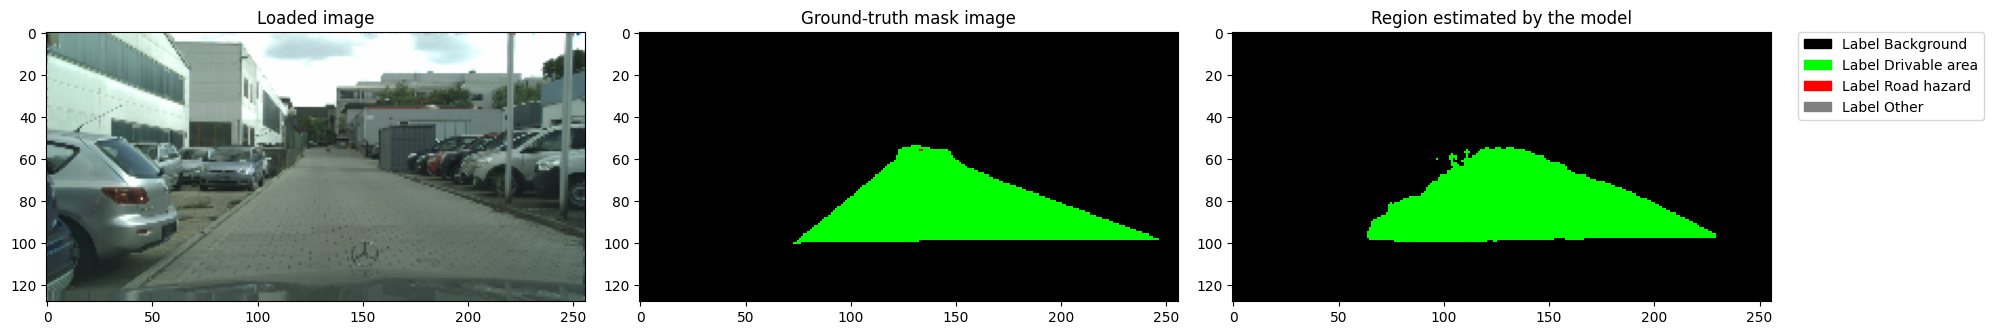

In [ ]:
# Test dataset
show_predictions(test_dataset, num=1)